<a href="https://colab.research.google.com/github/SrileakhanaMangapathi/multi-task-financial-news-analysis/blob/main/notebooks/02_distilbert_multitask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Notebook 2: DistilBERT Multi-Task Classification

**Architecture:** Fine-tuned DistilBERT with two classification heads

**Tasks:**
- Task 1: Market Event Classification (20 classes)
- Task 2: Sentiment Analysis (Positive / Negative / Neutral)

**Key techniques:**
- Discriminative learning rates (lower LR for base layers, higher for heads)
- Task-specific loss weighting
- fp16 mixed precision training
- Early stopping with model checkpointing

In [ ]:
!git clone https://github.com/SrileakhanaMangapathi/multi-task-financial-news-analysis.git
%cd multi-task-financial-news-analysis
!pip install -r requirements.txt

import os
os.makedirs("data/processed", exist_ok=True)
os.makedirs("models/saved", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)

import pandas as pd
df = pd.read_csv("data/raw/financial_news_events.csv")
df = df.dropna(subset=["Headline", "Sentiment"])
df["Index_Change_Percent"] = df["Index_Change_Percent"].fillna(
    df["Index_Change_Percent"].median()
)
df.to_csv("data/processed/financial_news_clean.csv", index=False)
print(f"Ready! Shape: {df.shape}")

fatal: destination path 'multi-task-financial-news-analysis' already exists and is not an empty directory.
/content/multi-task-financial-news-analysis
Ready! Shape: (2714, 12)


In [ ]:
# ── Install required packages ────────────────────────────────────────────────
!pip install transformers torch accelerate scikit-learn matplotlib seaborn

In [ ]:
# ── Import all required libraries ────────────────────────────────────────────
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertModel,
    get_linear_schedule_with_warmup
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Set device: use GPU if available (Colab T4/A100), else CPU ───────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 📂 Step 1: Load & Encode Labels

In [ ]:
# ── Load the cleaned dataset (output from Notebook 01_EDA) ──────────────────
df = pd.read_csv("data/processed/financial_news_clean.csv")
print(f"Dataset loaded: {df.shape[0]} rows")

# ── Encode string labels to integers for model training ──────────────────────
# LabelEncoder converts: "Positive" -> 0, "Negative" -> 1, "Neutral" -> 2 etc.
le_event = LabelEncoder()
le_sentiment = LabelEncoder()

df["event_label"] = le_event.fit_transform(df["Market_Event"])
df["sentiment_label"] = le_sentiment.fit_transform(df["Sentiment"])

NUM_EVENTS = len(le_event.classes_)
NUM_SENTIMENTS = len(le_sentiment.classes_)

print(f"Market Event classes ({NUM_EVENTS}): {le_event.classes_.tolist()}")
print(f"Sentiment classes ({NUM_SENTIMENTS}): {le_sentiment.classes_.tolist()}")

Dataset loaded: 2714 rows
Market Event classes (20): ['Bond Market Fluctuation', 'Central Bank Meeting', 'Commodity Price Shock', 'Consumer Confidence Report', 'Corporate Earnings Report', 'Cryptocurrency Regulation', 'Currency Devaluation', 'Economic Data Release', 'Geopolitical Event', 'Government Policy Announcement', 'IPO Launch', 'Inflation Data Release', 'Interest Rate Change', 'Major Merger/Acquisition', 'Market Rally', 'Regulatory Changes', 'Stock Market Crash', 'Supply Chain Disruption', 'Trade Tariffs Announcement', 'Unemployment Rate Announcement']
Sentiment classes (3): ['Negative', 'Neutral', 'Positive']


In [ ]:
# ── Stratified train/val/test split: 70 / 15 / 15 ───────────────────────────
# Stratified = each split has proportional class representation
# Important for 20-class Market Event to avoid class imbalance in splits

train_df, temp_df = train_test_split(
    df, test_size=0.30,
    stratify=df["event_label"],   # stratify on Market Event (most imbalanced)
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["event_label"],
    random_state=42
)

print(f"Train : {len(train_df)} rows ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df)} rows ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df)} rows ({len(test_df)/len(df)*100:.1f}%)")

Train : 1899 rows (70.0%)
Val   : 407 rows (15.0%)
Test  : 408 rows (15.0%)


## 🏗️ Step 2: Dataset Class

In [ ]:
class FinancialNewsDataset(Dataset):
    """
    PyTorch Dataset for financial news headlines.
    Tokenizes headlines using DistilBERT tokenizer and returns
    input_ids, attention_mask, and both task labels.
    """
    def __init__(self, df, tokenizer, max_len=128):
        self.headlines = df["Headline"].tolist()
        self.event_labels = df["event_label"].tolist()
        self.sentiment_labels = df["sentiment_label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.headlines)

    def __getitem__(self, idx):
        # Tokenize the headline: adds [CLS], [SEP], pads to max_len
        enc = self.tokenizer(
            self.headlines[idx],
            max_length=self.max_len,
            padding="max_length",    # pad shorter sequences
            truncation=True,          # truncate longer sequences
            return_tensors="pt"
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(),        # token ids
            "attention_mask" : enc["attention_mask"].squeeze(),    # 1=real, 0=pad
            "event_label"    : torch.tensor(self.event_labels[idx], dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long)
        }

## 🧠 Step 3: DistilBERT Multi-Task Model

In [ ]:
class DistilBertMultiTask(nn.Module):
    """
    Multi-task model built on top of pre-trained DistilBERT.

    Architecture:
        DistilBERT base
            |
        [CLS] token representation (768-dim)
            |          |
        Event Head   Sentiment Head
        (20 classes) (3 classes)

    Why [CLS] token?
        DistilBERT encodes the full sentence into the [CLS] token,
        making it ideal for sentence-level classification tasks.
    """
    def __init__(self, num_event_classes, num_sentiment_classes, dropout=0.3):
        super().__init__()

        # Load pre-trained DistilBERT (66M params, smaller/faster than BERT)
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        hidden_size = self.bert.config.hidden_size  # 768

        # Task 1: Market Event classification head
        # Dropout for regularization, Linear for classification
        self.event_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_event_classes)
        )

        # Task 2: Sentiment classification head
        self.sentiment_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_sentiment_classes)
        )

    def forward(self, input_ids, attention_mask):
        # Pass tokens through DistilBERT transformer layers
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        # Extract [CLS] token (index 0) as sentence representation
        cls_representation = bert_output.last_hidden_state[:, 0, :]  # shape: (batch, 768)

        # Pass through task-specific heads
        event_logits = self.event_head(cls_representation)        # shape: (batch, 20)
        sentiment_logits = self.sentiment_head(cls_representation) # shape: (batch, 3)

        return event_logits, sentiment_logits

## 🚀 Step 4: Training Setup

In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE = 32    # number of samples per gradient update
EPOCHS     = 20    # maximum training epochs
PATIENCE   = 3     # early stopping: stop if no improvement for 3 epochs
MAX_LEN    = 128   # max tokens per headline

# ── Initialize tokenizer (same vocab as DistilBERT pre-training) ─────────────
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# ── Create DataLoaders ────────────────────────────────────────────────────────
# shuffle=True for training to prevent learning order patterns
train_loader = DataLoader(FinancialNewsDataset(train_df, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(FinancialNewsDataset(val_df, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(FinancialNewsDataset(test_df, tokenizer, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False)

# ── Initialize model ─────────────────────────────────────────────────────────
model = DistilBertMultiTask(NUM_EVENTS, NUM_SENTIMENTS).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

[Widget output - run in Colab to see progress bar]


DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model parameters: 66,380,567


In [ ]:
# ── Discriminative learning rates ─────────────────────────────────────────────
# Key technique: Use LOWER LR for pre-trained BERT layers (preserve pre-trained knowledge)
#                Use HIGHER LR for new classification heads (learn task-specific patterns)
# This avoids catastrophic forgetting of BERT pre-training

optimizer = torch.optim.AdamW([
    {"params": model.bert.parameters(),           "lr": 1e-5},   # base: slow update
    {"params": model.event_head.parameters(),     "lr": 3e-5},   # head: faster update
    {"params": model.sentiment_head.parameters(), "lr": 3e-5},   # head: faster update
], weight_decay=0.01)  # L2 regularization to prevent overfitting

# ── Linear learning rate warmup then decay ───────────────────────────────────
# Warmup avoids large gradient updates at the start of fine-tuning
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=100,
    num_training_steps=len(train_loader) * EPOCHS
)

# ── Loss function: CrossEntropy for multi-class classification ───────────────
criterion = nn.CrossEntropyLoss()

# ── fp16 mixed precision scaler ──────────────────────────────────────────────
# Reduces GPU memory usage and speeds up training on Colab GPU
scaler = torch.cuda.amp.GradScaler()

## 🔁 Step 5: Training & Validation Loop

In [ ]:
def train_one_epoch(model, loader):
    """Train model for one full epoch. Returns average loss."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        # Move data to GPU/CPU
        input_ids  = batch["input_ids"].to(DEVICE)
        attn_mask  = batch["attention_mask"].to(DEVICE)
        e_labels   = batch["event_label"].to(DEVICE)
        s_labels   = batch["sentiment_label"].to(DEVICE)

        optimizer.zero_grad()  # clear gradients from previous batch

        # fp16 autocast: automatically casts ops to float16 where safe
        with torch.cuda.amp.autocast():
            e_logits, s_logits = model(input_ids, attn_mask)

            # Multi-task loss: equal weighting (0.5 each task)
            # Can adjust weights if one task is more important
            loss = (0.5 * criterion(e_logits, e_labels) +
                    0.5 * criterion(s_logits, s_labels))

        # Backpropagation with gradient scaling (for fp16 stability)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()  # update learning rate

        total_loss += loss.item()

    return total_loss / len(loader)  # average loss per batch


def evaluate(model, loader):
    """Evaluate model. Returns F1 scores and raw predictions."""
    model.eval()
    e_preds, e_true = [], []
    s_preds, s_true = [], []

    with torch.no_grad():  # no gradient computation during eval
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)

            e_logits, s_logits = model(input_ids, attn_mask)

            # argmax gives predicted class index
            e_preds.extend(e_logits.argmax(dim=1).cpu().numpy())
            e_true.extend(batch["event_label"].numpy())
            s_preds.extend(s_logits.argmax(dim=1).cpu().numpy())
            s_true.extend(batch["sentiment_label"].numpy())

    # Macro F1: treats all classes equally (good for imbalanced classes)
    e_f1 = f1_score(e_true, e_preds, average="macro")
    s_f1 = f1_score(s_true, s_preds, average="macro")

    return e_f1, s_f1, e_preds, e_true, s_preds, s_true

In [ ]:
# ── Main training loop with early stopping ────────────────────────────────────
best_val_f1       = 0.0
patience_counter  = 0
train_losses      = []
val_f1_history    = []

print("Starting training...")
print(f"{'Epoch':<8} {'Loss':<12} {'Event F1':<14} {'Sent F1':<12} {'Avg F1'}")
print("-" * 55)

for epoch in range(EPOCHS):
    # Train
    train_loss = train_one_epoch(model, train_loader)

    # Validate
    e_f1, s_f1, _, _, _, _ = evaluate(model, val_loader)
    avg_f1 = (e_f1 + s_f1) / 2

    train_losses.append(train_loss)
    val_f1_history.append(avg_f1)

    print(f"{epoch+1:<8} {train_loss:<12.4f} {e_f1:<14.4f} {s_f1:<12.4f} {avg_f1:.4f}")

    # Save best model checkpoint
    if avg_f1 > best_val_f1:
        best_val_f1 = avg_f1
        torch.save(model.state_dict(), "models/saved/distilbert_best.pt")
        patience_counter = 0
        print(f"         -> New best model saved! (F1={best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            print(f"No improvement for {PATIENCE} consecutive epochs.")
            break

print(f"Best Validation F1: {best_val_f1:.4f}")

Starting training...
Epoch    Loss         Event F1       Sent F1      Avg F1
-------------------------------------------------------
1        2.0738       0.0121         0.3035       0.1578
         -> New best model saved! (F1=0.1578)
2        2.0557       0.0226         0.2712       0.1469
3        2.0481       0.0139         0.2522       0.1331
4        2.0410       0.0287         0.3121       0.1704
         -> New best model saved! (F1=0.1704)
5        2.0355       0.0288         0.2848       0.1568
6        2.0322       0.0332         0.2953       0.1643
7        2.0255       0.0362         0.3120       0.1741
         -> New best model saved! (F1=0.1741)
8        2.0156       0.0352         0.3049       0.1701
9        2.0126       0.0408         0.3089       0.1749
         -> New best model saved! (F1=0.1749)
10       2.0006       0.0453         0.3120       0.1787
         -> New best model saved! (F1=0.1787)
11       2.0007       0.0418         0.2858       0.1638
12       

## 📊 Step 6: Evaluation on Test Set

In [ ]:
# ── Load best saved model for final evaluation ───────────────────────────────
model.load_state_dict(torch.load("models/saved/distilbert_best.pt"))
print("Best model loaded for test evaluation.")

# ── Run evaluation on held-out test set ──────────────────────────────────────
e_f1, s_f1, e_preds, e_true, s_preds, s_true = evaluate(model, test_loader)

# ── Market Event results ──────────────────────────────────────────────────────
print("=" * 60)
print("TASK 1: Market Event Classification")
print("=" * 60)
print(classification_report(e_true, e_preds, target_names=le_event.classes_))
print(f"Cohen Kappa Score : {cohen_kappa_score(e_true, e_preds):.4f}")
print(f"Matthews Corr Coef: {matthews_corrcoef(e_true, e_preds):.4f}")

# ── Sentiment results ─────────────────────────────────────────────────────────
print("" + "=" * 60)
print("TASK 2: Sentiment Analysis")
print("=" * 60)
print(classification_report(s_true, s_preds, target_names=le_sentiment.classes_))
print(f"Cohen Kappa Score : {cohen_kappa_score(s_true, s_preds):.4f}")
print(f"Matthews Corr Coef: {matthews_corrcoef(s_true, s_preds):.4f}")

Best model loaded for test evaluation.
TASK 1: Market Event Classification
                                precision    recall  f1-score   support

       Bond Market Fluctuation       0.04      0.05      0.05        19
          Central Bank Meeting       0.00      0.00      0.00        22
         Commodity Price Shock       0.08      0.09      0.08        23
    Consumer Confidence Report       0.07      0.19      0.10        21
     Corporate Earnings Report       0.03      0.05      0.04        22
     Cryptocurrency Regulation       0.06      0.06      0.06        17
          Currency Devaluation       0.00      0.00      0.00        18
         Economic Data Release       0.04      0.05      0.04        20
            Geopolitical Event       0.00      0.00      0.00        18
Government Policy Announcement       0.05      0.04      0.05        23
                    IPO Launch       0.00      0.00      0.00        21
        Inflation Data Release       0.00      0.00      0.0

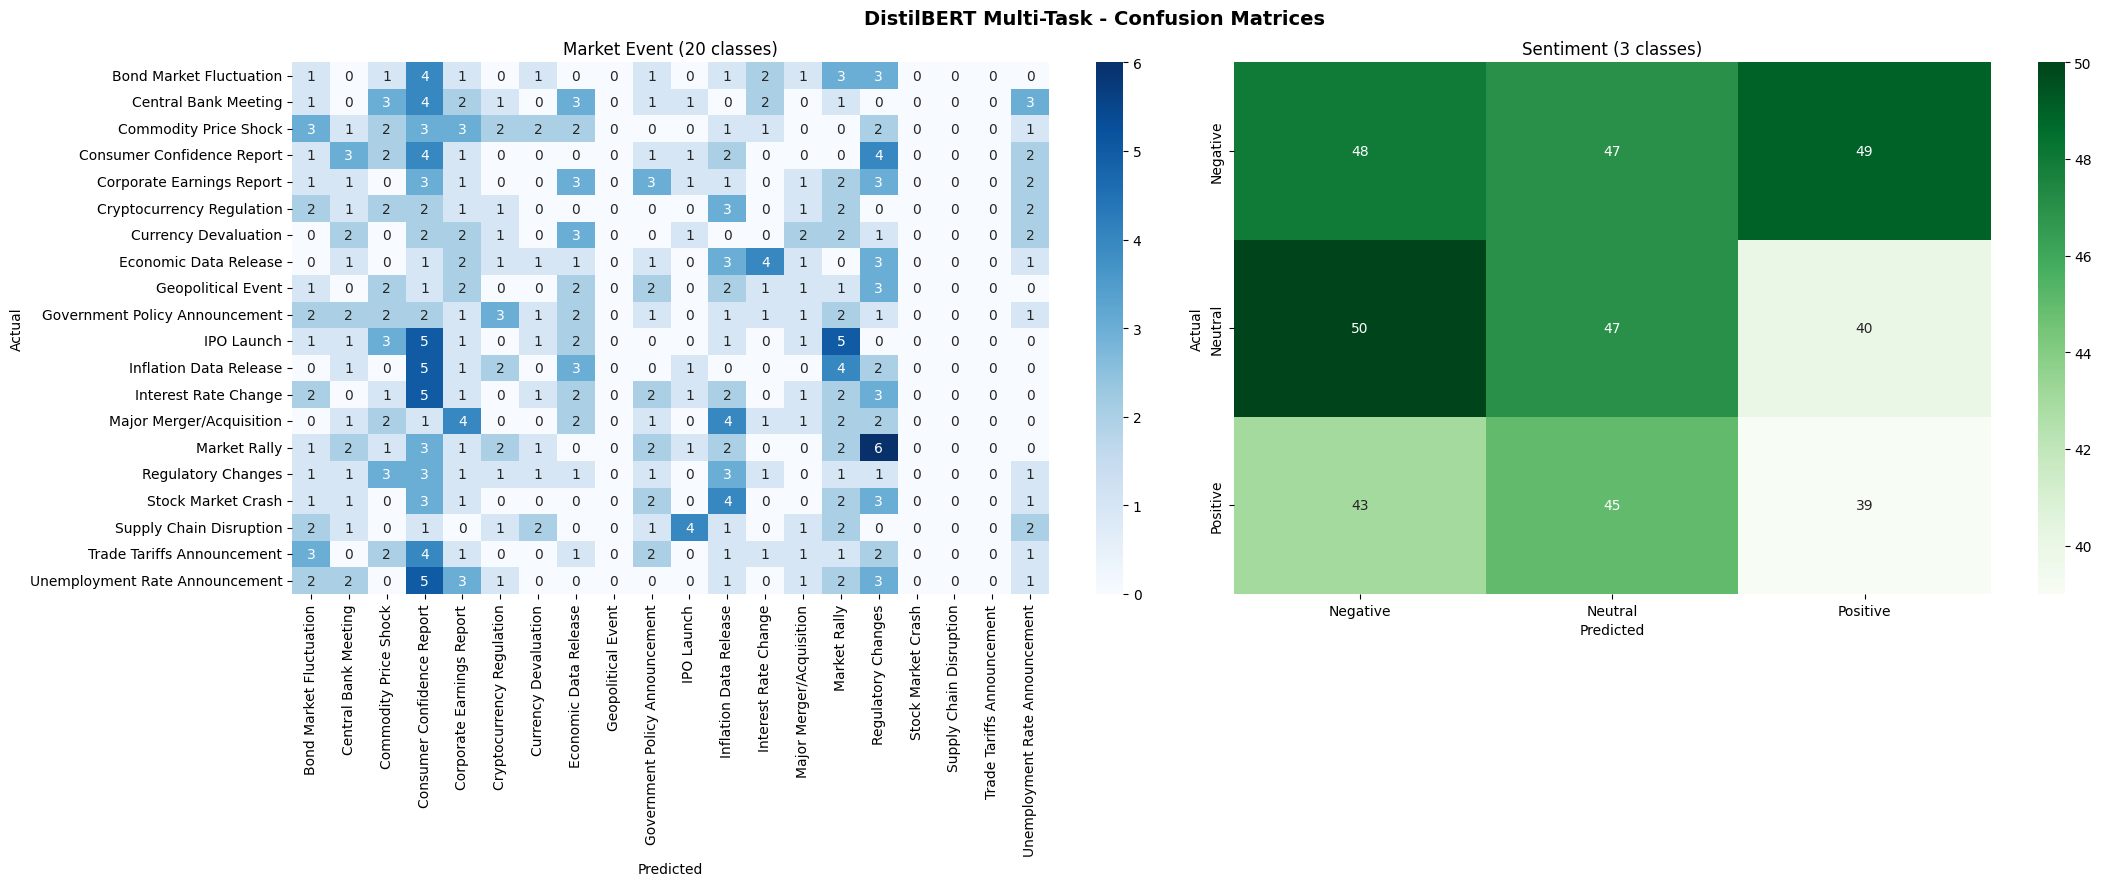

Confusion matrices saved.


In [ ]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
# Confusion matrix shows where the model makes mistakes across classes

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle("DistilBERT Multi-Task - Confusion Matrices", fontsize=14, fontweight="bold")

# Market Event confusion matrix
sns.heatmap(
    confusion_matrix(e_true, e_preds),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=le_event.classes_,
    yticklabels=le_event.classes_,
    ax=axes[0]
)
axes[0].set_title("Market Event (20 classes)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=90)

# Sentiment confusion matrix
sns.heatmap(
    confusion_matrix(s_true, s_preds),
    annot=True, fmt="d", cmap="Greens",
    xticklabels=le_sentiment.classes_,
    yticklabels=le_sentiment.classes_,
    ax=axes[1]
)
axes[1].set_title("Sentiment (3 classes)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("results/plots/distilbert_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved.")

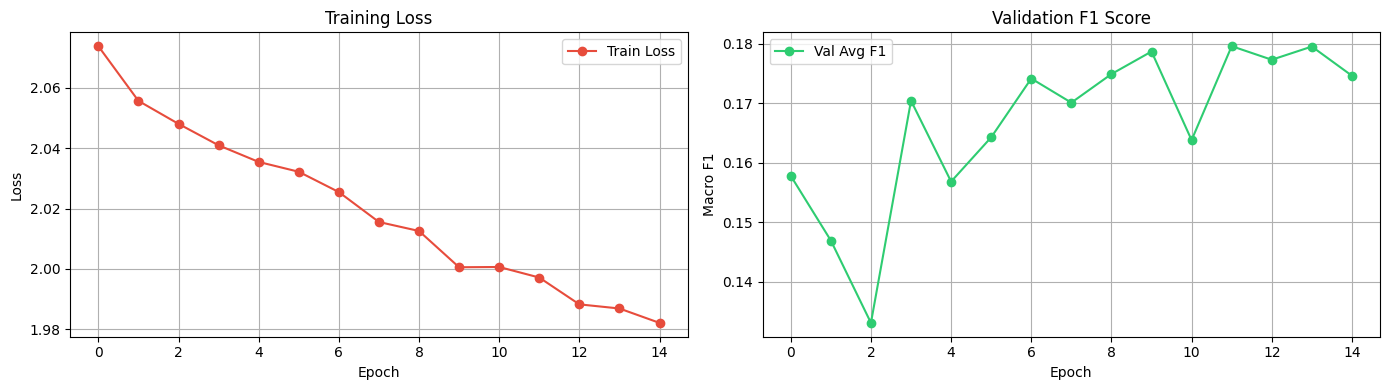

In [ ]:
# ── Training curve: Loss and F1 over epochs ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, marker="o", color="#e74c3c", label="Train Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_f1_history, marker="o", color="#2ecc71", label="Val Avg F1")
axes[1].set_title("Validation F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("results/plots/distilbert_training_curves.png", dpi=150)
plt.show()

In [ ]:
# ── Save evaluation metrics to CSV ────────────────────────────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    "Model"           : "DistilBERT",
    "Event_Macro_F1"  : round(f1_score(e_true, e_preds, average="macro"), 4),
    "Event_Weighted_F1": round(f1_score(e_true, e_preds, average="weighted"), 4),
    "Event_Kappa"     : round(cohen_kappa_score(e_true, e_preds), 4),
    "Event_MCC"       : round(matthews_corrcoef(e_true, e_preds), 4),
    "Sent_Macro_F1"   : round(f1_score(s_true, s_preds, average="macro"), 4),
    "Sent_Weighted_F1": round(f1_score(s_true, s_preds, average="weighted"), 4),
    "Sent_Kappa"      : round(cohen_kappa_score(s_true, s_preds), 4),
    "Sent_MCC"        : round(matthews_corrcoef(s_true, s_preds), 4),
}

pd.DataFrame([metrics]).to_csv("results/metrics/distilbert_metrics.csv", index=False)
print("Metrics saved to results/metrics/distilbert_metrics.csv")
print(pd.DataFrame([metrics]).T)

Metrics saved to results/metrics/distilbert_metrics.csv
                            0
Model              DistilBERT
Event_Macro_F1         0.0308
Event_Weighted_F1      0.0319
Event_Kappa           -0.0129
Event_MCC             -0.0131
Sent_Macro_F1          0.3278
Sent_Weighted_F1       0.3285
Sent_Kappa            -0.0084
Sent_MCC              -0.0084
